# **Sistema de Control de Glucosa con RL**

1. Librerias

In [9]:
import numpy as np
import random
import pandas as pd
import pickle
import pygame
import matplotlib.pyplot as plt
from collections import deque, defaultdict
import time
import math

# **pregunta de examen**
Modifica el código para que se pueda agregar en la discretización, la edad, el peso y genero

2. Clase Entorno

In [10]:
class EntornoPaciente:
    """Entorno realista de control de glucosa con modelo fisiológico,
    incluyendo parámetros del paciente para discretización."""
    
    def __init__(self, edad=40, peso=70, genero='H'):
        # Parámetros fisiológicos
        self.glucosa_min = 40
        self.glucosa_max = 300
        self.glucosa_objetivo = 100
        self.rango_seguro = (80, 120)
        
        # --- NUEVOS PARÁMETROS DEL PACIENTE ---
        self.edad = edad
        self.peso = peso
        self.genero = genero  # 'H' (Hombre) o 'M' (Mujer)
        
        # La sensibilidad a la insulina puede depender de estos factores
        # Se incluye una base, y se puede ajustar en reset() o paso()
        self.sensibilidad_base = 40 
        
        # Insulina
        self.insulina_activa = 0.0
        self.vida_media_insulina = 4
        self.sensibilidad_insulina = self.sensibilidad_base # Se recalcula en reset
        self.dosis_base = 1.0
        
        # Estado actual
        self.glucosa_actual = 150
        self.tiempo_hora = 0
        self.comida_reciente = False
        
        # Acciones
        self.acciones = {
            'AUM_DOSIS': 1.5,
            'MANTENER': 1.0,
            'RED_DOSIS': 0.5,
            'NO_INSULINA': 0.0
        }
        
        # Historial
        self.historial_glucosa = deque(maxlen=100)
        self.historial_acciones = deque(maxlen=100)
        self.historial_recompensas = deque(maxlen=100)
        
        self.ruido_metabolico = 5
    
    def reset(self):
        """Reinicia con estado inicial aleatorio y recalcula la sensibilidad."""
        
        # --- SIMULACIÓN DE PACIENTES DIVERSOS EN CADA EPISODIO ---
        # Puedes fijar estos valores si quieres un paciente estático
        # o dejar la aleatoriedad para entrenar a un agente más robusto.
        self.edad = np.random.randint(20, 80)
        self.peso = np.random.uniform(50, 100)
        self.genero = np.random.choice(['H', 'M'])
        
        # Ajuste simple de sensibilidad (ejemplo)
        # Mujeres (M) suelen tener una sensibilidad ligeramente mayor (menos resistencia)
        ajuste_genero = 1.0 if self.genero == 'H' else 1.1 
        # Jóvenes o delgados pueden ser más sensibles
        ajuste_edad_peso = 1 + ((80 - self.edad) / 100) * ((100 - self.peso) / 100) * 0.5
        self.sensibilidad_insulina = self.sensibilidad_base * ajuste_genero * ajuste_edad_peso
        # Asegurarse de que no sea un valor absurdo
        self.sensibilidad_insulina = np.clip(self.sensibilidad_insulina, 20, 70) 

        self.glucosa_actual = np.random.uniform(140, 200)
        self.tiempo_hora = np.random.randint(0, 24)
        self.insulina_activa = 0.0
        self.comida_reciente = np.random.choice([True, False])
        
        self.historial_glucosa.clear()
        self.historial_acciones.clear()
        self.historial_recompensas.clear()
        
        return self._obtener_estado()
    
    def _obtener_estado(self):
        """Estado discretizado, incluyendo edad, peso y género."""
        
        # 1. Nivel de Glucosa (0: BAJA, 1: NORMAL, 2: ALTA)
        if self.glucosa_actual < 70:
            glucosa_nivel = 0
        elif self.glucosa_actual <= 140:
            glucosa_nivel = 1
        else:
            glucosa_nivel = 2
        
        # 2. Periodo del Día (0-3: cuartos del día)
        periodo = self.tiempo_hora // 6
        
        # 3. Comida Reciente (0: No, 1: Sí)
        comida = 1 if self.comida_reciente else 0
        
        # 4. Edad Discretizada (0: Joven, 1: Adulto, 2: Mayor)
        if self.edad < 40:
            edad_nivel = 0
        elif self.edad <= 65:
            edad_nivel = 1
        else:
            edad_nivel = 2
            
        # 5. Peso Discretizado (0: Delgado, 1: Normal, 2: Sobrepeso/Obeso)
        # Uso de IMC simplificado: Peso / (1.75**2) ~ 22.86,
        # Asumiendo una altura media de 1.75m.
        # <60kg -> Delgado (IMC < 20)
        # 60-85kg -> Normal (IMC 20-28)
        # >85kg -> Obeso (IMC > 28)
        if self.peso < 60:
            peso_nivel = 0
        elif self.peso <= 85:
            peso_nivel = 1
        else:
            peso_nivel = 2
            
        # 6. Género (0: Hombre 'H', 1: Mujer 'M')
        genero_codificado = 1 if self.genero == 'M' else 0
        
        # El estado es una tupla de 6 elementos
        return (glucosa_nivel, periodo, comida, edad_nivel, peso_nivel, genero_codificado)
    
    # El resto de los métodos se mantienen igual, solo se actualiza la sensibilidad
    # y la glucosa actual en base a los nuevos parámetros en reset y paso.
    
    def obtener_clave_estado(self):
        """Estado como string para la tabla Q."""
        estado = self._obtener_estado()
        return ",".join(map(str, estado))

    def obtener_acciones_validas(self):
        """Lista de acciones."""
        return list(self.acciones.keys())
    
    def obtener_info_estado(self):
        """Info legible del estado."""
        if self.glucosa_actual < 70:
            nivel = "BAJA"
        elif self.glucosa_actual <= 140:
            nivel = "NORMAL"
        else:
            nivel = "ALTA"
        
        return nivel, f"{self.tiempo_hora:02d}:00", f"{self.glucosa_actual:.1f} mg/dL"

    def paso(self, accion_nombre):
        """Simula un paso temporal."""
        # Aplicar insulina
        dosis = self.acciones[accion_nombre] * self.dosis_base
        self.insulina_activa += dosis
        
        # Efecto insulina (depende de la sensibilidad ajustada en reset)
        reduccion = self.insulina_activa * self.sensibilidad_insulina / 100.0 # Normalización
        self.glucosa_actual -= reduccion
        
        # Degradación insulina
        self.insulina_activa *= (0.5 ** (1/self.vida_media_insulina))
        
        # Producción hepática (puede ser ajustada por peso/edad/género si es necesario)
        self.glucosa_actual += 5
        
        # Comida
        if self.comida_reciente:
            self.glucosa_actual += 30
            self.comida_reciente = False
        
        if np.random.random() < 0.1:
            self.comida_reciente = True
        
        # Ruido
        self.glucosa_actual += np.random.uniform(-self.ruido_metabolico, 
                                                  self.ruido_metabolico)
        
        # Límites
        self.glucosa_actual = np.clip(self.glucosa_actual, 
                                       self.glucosa_min, 
                                       self.glucosa_max)
        
        self.tiempo_hora = (self.tiempo_hora + 1) % 24
        
        # Recompensa
        recompensa = self._calcular_recompensa(accion_nombre)
        
        # Historial
        self.historial_glucosa.append(self.glucosa_actual)
        self.historial_acciones.append(accion_nombre)
        self.historial_recompensas.append(recompensa)
        
        terminado = self.glucosa_actual < 50
        
        return self.obtener_clave_estado(), recompensa, terminado
    
    def _calcular_recompensa(self, accion):
        """Sistema de recompensas realista."""
        r = 0
        
        # En rango óptimo
        if self.rango_seguro[0] <= self.glucosa_actual <= self.rango_seguro[1]:
            r += 10
            dist = abs(self.glucosa_actual - self.glucosa_objetivo)
            r += max(0, 5 - dist / 4)
        
        # Hipoglucemia
        if self.glucosa_actual < 70:
            r -= (70 - self.glucosa_actual) * 0.5
            if self.glucosa_actual < 50:
                r -= 50
        
        # Hiperglucemia
        if self.glucosa_actual > 180:
            r -= (self.glucosa_actual - 180) * 0.3
        
        # Variabilidad
        if len(self.historial_glucosa) >= 2:
            cambio = abs(self.glucosa_actual - self.historial_glucosa[-1])
            if cambio > 30:
                r -= 2
        
        # Eficiencia
        if self.rango_seguro[0] <= self.glucosa_actual <= self.rango_seguro[1]:
            if accion in ['MANTENER', 'NO_INSULINA']:
                r += 2
        
        r -= 0.1  # Penalización por paso
        
        return r

3. Agente Q-Learning

In [11]:
class AgenteQLearning:
    """Agente que aprende con Q-Learning."""
    
    def __init__(self, alfa=0.1, gamma=0.95, epsilon=1.0):
        self.alfa = alfa
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        
        self.tabla_q = defaultdict(float)
        
        self.pasos_totales = 0
        self.episodios_completados = 0
    
    def obtener_q_valor(self, estado, accion):
        """Q(s,a)"""
        return self.tabla_q[(estado, accion)]
    
    def obtener_mejor_accion(self, estado, acciones):
        """Política codiciosa."""
        valores_q = [self.obtener_q_valor(estado, a) for a in acciones]
        max_q = max(valores_q)
        mejores = [a for a, q in zip(acciones, valores_q) if q == max_q]
        return random.choice(mejores)
    
    def elegir_accion(self, entorno, explorar=True):
        """Epsilon-codiciosa."""
        acciones = entorno.obtener_acciones_validas()
        estado = entorno.obtener_clave_estado()
        
        if explorar and random.random() < self.epsilon:
            return random.choice(acciones)
        
        return self.obtener_mejor_accion(estado, acciones)
    
    def actualizar(self, estado, accion, recompensa, siguiente_estado, 
                   acciones_siguiente, terminado):
        """Actualización Q-Learning."""
        q_actual = self.obtener_q_valor(estado, accion)
        
        if terminado:
            objetivo = recompensa
        else:
            max_q = max([self.obtener_q_valor(siguiente_estado, a) 
                        for a in acciones_siguiente])
            objetivo = recompensa + self.gamma * max_q
        
        nuevo_q = q_actual + self.alfa * (objetivo - q_actual)
        self.tabla_q[(estado, accion)] = nuevo_q
        
        self.pasos_totales += 1
    
    def decrementar_epsilon(self):
        """Reduce exploración."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
    
    def guardar_modelo(self, archivo="modelo_glucosa.pkl"):
        """Guarda modelo."""
        datos = {
            'tabla_q': dict(self.tabla_q),
            'alfa': self.alfa,
            'gamma': self.gamma,
            'epsilon': self.epsilon,
            'pasos': self.pasos_totales,
            'episodios': self.episodios_completados
        }
        with open(archivo, 'wb') as f:
            pickle.dump(datos, f)
        print(f"✓ Modelo guardado: {archivo}")
    
    def cargar_modelo(self, archivo="modelo_glucosa.pkl"):
        """Carga modelo."""
        try:
            with open(archivo, 'rb') as f:
                datos = pickle.load(f)
            
            self.tabla_q = defaultdict(float, datos['tabla_q'])
            self.alfa = datos['alfa']
            self.gamma = datos['gamma']
            self.epsilon = datos.get('epsilon', 0.01)
            self.pasos_totales = datos.get('pasos', 0)
            self.episodios_completados = datos.get('episodios', 0)
            
            print(f"✓ Modelo cargado: {archivo}")
            return True
        except FileNotFoundError:
            print(f"✗ No existe: {archivo}")
            return False

4. Funciones de Entrenamiento

In [12]:
def entrenar_agente(agente, entorno, num_episodios=5000, pasos_por_episodio=50, 
                   verbose=True):
    """Entrena el agente."""
    if verbose:
        print(f"🚀 Entrenamiento: {num_episodios} episodios")
        print(f"   α={agente.alfa}, γ={agente.gamma}, ε={agente.epsilon}\n")
    
    historial_recompensas = []
    mejor_recompensa = -float('inf')
    ventana = deque(maxlen=100)
    
    for ep in range(num_episodios):
        estado = entorno.reset()
        r_total = 0
        
        for _ in range(pasos_por_episodio):
            accion = agente.elegir_accion(entorno, explorar=True)
            siguiente, recompensa, terminado = entorno.paso(accion)
            
            acciones_sig = entorno.obtener_acciones_validas()
            agente.actualizar(estado, accion, recompensa, siguiente, 
                            acciones_sig, terminado)
            
            r_total += recompensa
            estado = siguiente
            
            if terminado:
                break
        
        historial_recompensas.append(r_total)
        ventana.append(r_total)
        agente.episodios_completados += 1
        agente.decrementar_epsilon()
        
        if r_total > mejor_recompensa:
            mejor_recompensa = r_total
            agente.guardar_modelo("mejor_modelo_glucosa.pkl")
        
        if verbose and (ep + 1) % 100 == 0:
            promedio = np.mean(ventana)
            print(f"Episodio {ep+1:5d} | R: {promedio:7.2f} | ε: {agente.epsilon:.3f}")
    
    agente.guardar_modelo("modelo_final_glucosa.pkl")
    
    if verbose:
        print(f"\n✓ Entrenamiento completado")
        print(f"  Mejor recompensa: {mejor_recompensa:.2f}")
        print(f"  Estados Q: {len(agente.tabla_q)}")
    
    return historial_recompensas


def evaluar_agente(agente, entorno, num_episodios=100, pasos=50, verbose=True):
    """Evalúa desempeño."""
    if verbose:
        print(f"\n📊 Evaluación: {num_episodios} episodios")
    
    tiempo_rango = 0
    ep_hipo = 0
    ep_hiper = 0
    glucosas = []
    variabilidades = []
    recompensas = []
    
    for _ in range(num_episodios):
        entorno.reset()
        valores_g = []
        r_total = 0
        
        for _ in range(pasos):
            accion = agente.elegir_accion(entorno, explorar=False)
            _, r, terminado = entorno.paso(accion)
            
            r_total += r
            valores_g.append(entorno.glucosa_actual)
            
            if 80 <= entorno.glucosa_actual <= 120:
                tiempo_rango += 1
            
            if terminado:
                break
        
        if any(g < 70 for g in valores_g):
            ep_hipo += 1
        if any(g > 180 for g in valores_g):
            ep_hiper += 1
        
        glucosas.append(np.mean(valores_g))
        variabilidades.append(np.std(valores_g))
        recompensas.append(r_total)
    
    pct_rango = (tiempo_rango / (num_episodios * pasos)) * 100
    
    if verbose:
        print(f"\n📈 Resultados:")
        print(f"  Tiempo en rango: {pct_rango:.1f}%")
        print(f"  Hipoglucemia: {ep_hipo}/{num_episodios}")
        print(f"  Hiperglucemia: {ep_hiper}/{num_episodios}")
        print(f"  Glucosa promedio: {np.mean(glucosas):.1f} mg/dL")
        print(f"  Variabilidad: {np.mean(variabilidades):.1f} mg/dL")
        print(f"  Recompensa: {np.mean(recompensas):.2f}")
    
    return {
        'tiempo_rango': pct_rango,
        'hipo': ep_hipo,
        'hiper': ep_hiper,
        'glucosa_prom': np.mean(glucosas),
        'variabilidad': np.mean(variabilidades),
        'recompensa': np.mean(recompensas)
    }

5. Visualización con Matplotlib

In [13]:
def graficar_entrenamiento(historial_recompensas, ventana=100):
    """Gráfica de recompensas durante entrenamiento."""
    plt.figure(figsize=(12, 5))
    
    # Recompensas
    plt.subplot(1, 2, 1)
    plt.plot(historial_recompensas, alpha=0.3, label='Por episodio')
    
    # Media móvil
    media_movil = pd.Series(historial_recompensas).rolling(ventana).mean()
    plt.plot(media_movil, linewidth=2, label=f'Media móvil ({ventana})')
    
    plt.xlabel('Episodio')
    plt.ylabel('Recompensa')
    plt.title('Progreso del Entrenamiento')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Histograma
    plt.subplot(1, 2, 2)
    plt.hist(historial_recompensas, bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('Recompensa')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Recompensas')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def simular_episodio_visual(agente, entorno, num_pasos=50):
    """Simula un episodio y lo grafica."""
    entorno.reset()
    
    glucosas = []
    recompensas = []
    acciones = []
    
    for _ in range(num_pasos):
        accion = agente.elegir_accion(entorno, explorar=False)
        _, r, terminado = entorno.paso(accion)
        
        glucosas.append(entorno.glucosa_actual)
        recompensas.append(r)
        acciones.append(accion)
        
        if terminado:
            break
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Glucosa
    axes[0].plot(glucosas, linewidth=2, marker='o', markersize=4)
    axes[0].axhline(y=120, color='g', linestyle='--', alpha=0.5, label='Límite superior')
    axes[0].axhline(y=80, color='g', linestyle='--', alpha=0.5, label='Límite inferior')
    axes[0].fill_between(range(len(glucosas)), 80, 120, alpha=0.2, color='green')
    axes[0].set_ylabel('Glucosa (mg/dL)')
    axes[0].set_title('Control de Glucosa - Episodio Simulado')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Recompensas y acciones
    axes[1].bar(range(len(recompensas)), recompensas, alpha=0.6)
    axes[1].set_xlabel('Paso')
    axes[1].set_ylabel('Recompensa')
    axes[1].set_title('Recompensas por Paso')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nAcciones tomadas: {', '.join(set(acciones))}")
    print(f"Glucosa final: {glucosas[-1]:.1f} mg/dL")
    print(f"Recompensa total: {sum(recompensas):.2f}")

6. Ejecución Principal

 S.U.C.RE - Sistema de Control de Glucosa v2.0

🔧 Fase 1: Entrenamiento
🚀 Entrenamiento: 5000 episodios
   α=0.1, γ=0.95, ε=1.0

✓ Modelo guardado: mejor_modelo_glucosa.pkl
✓ Modelo guardado: mejor_modelo_glucosa.pkl
✓ Modelo guardado: mejor_modelo_glucosa.pkl
✓ Modelo guardado: mejor_modelo_glucosa.pkl
✓ Modelo guardado: mejor_modelo_glucosa.pkl
Episodio   100 | R: -1487.41 | ε: 0.606
Episodio   200 | R: -1466.44 | ε: 0.367
✓ Modelo guardado: mejor_modelo_glucosa.pkl
Episodio   300 | R: -1443.11 | ε: 0.222
Episodio   400 | R: -1479.21 | ε: 0.135
Episodio   500 | R: -1484.34 | ε: 0.082
Episodio   600 | R: -1442.83 | ε: 0.049
Episodio   700 | R: -1466.97 | ε: 0.030
✓ Modelo guardado: mejor_modelo_glucosa.pkl
✓ Modelo guardado: mejor_modelo_glucosa.pkl
Episodio   800 | R: -1492.09 | ε: 0.018
Episodio   900 | R: -1456.49 | ε: 0.011
✓ Modelo guardado: mejor_modelo_glucosa.pkl
Episodio  1000 | R: -1430.56 | ε: 0.010
Episodio  1100 | R: -1439.64 | ε: 0.010
Episodio  1200 | R: -1516.85 | ε: 0

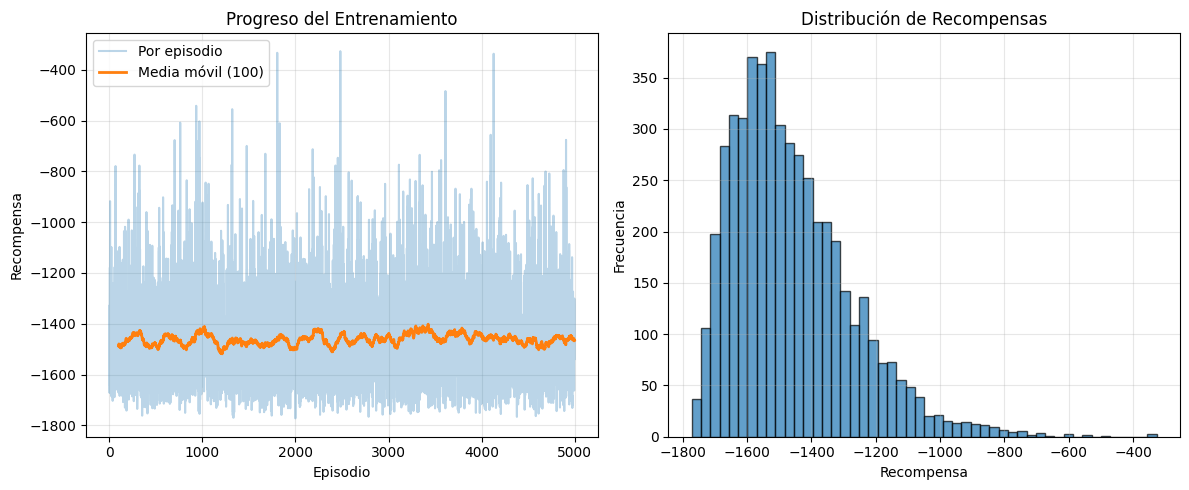


🎯 Fase 3: Evaluación

📊 Evaluación: 100 episodios

📈 Resultados:
  Tiempo en rango: 0.0%
  Hipoglucemia: 0/100
  Hiperglucemia: 100/100
  Glucosa promedio: 277.7 mg/dL
  Variabilidad: 33.5 mg/dL
  Recompensa: -1478.27

🎬 Fase 4: Simulación visual


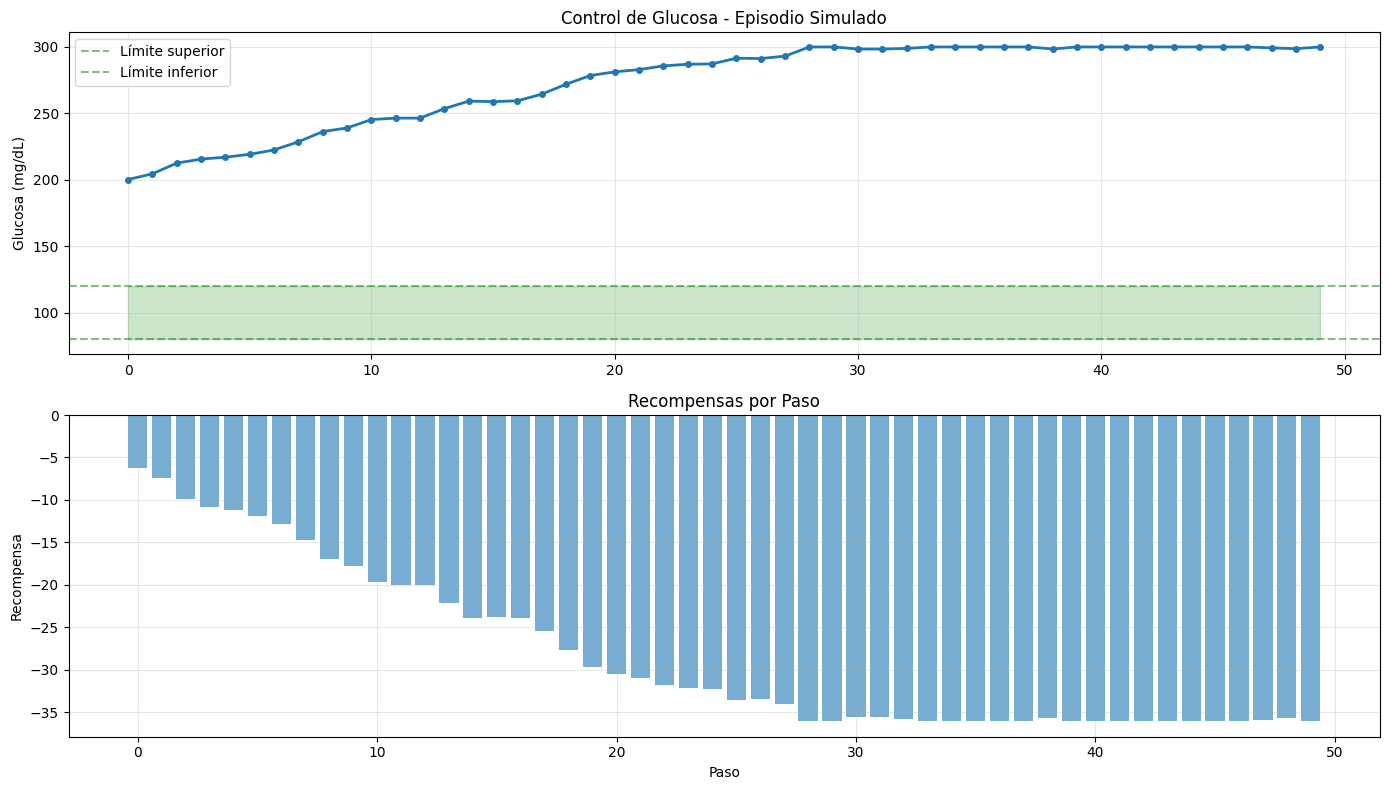


Acciones tomadas: NO_INSULINA, MANTENER, RED_DOSIS
Glucosa final: 300.0 mg/dL
Recompensa total: -1406.87

✓ Proceso completo finalizado


In [14]:
if __name__ == '__main__':
    print("="*70)
    print(" S.U.C.RE - Sistema de Control de Glucosa v2.0")
    print("="*70)
    
    # Crear entorno y agente
    entorno = EntornoPaciente()
    agente = AgenteQLearning(alfa=0.1, gamma=0.95, epsilon=1.0)
    
    # ENTRENAR
    print("\n🔧 Fase 1: Entrenamiento")
    historial = entrenar_agente(agente, entorno, num_episodios=5000, verbose=True)
    
    # GRAFICAR
    print("\n📊 Fase 2: Análisis visual")
    graficar_entrenamiento(historial)
    
    # EVALUAR
    print("\n🎯 Fase 3: Evaluación")
    metricas = evaluar_agente(agente, entorno, num_episodios=100, verbose=True)
    
    # SIMULAR
    print("\n🎬 Fase 4: Simulación visual")
    simular_episodio_visual(agente, entorno, num_pasos=50)
    
    print("\n✓ Proceso completo finalizado")

7. Visualización con Pygame + métricas en tiempo real

In [15]:
# Configuración
ANCHO, ALTO = 1200, 700
FPS = 60

# Colores modernos
COLOR_FONDO = (25, 30, 45)
COLOR_PANEL_FONDO = (35, 42, 60)
COLOR_PANEL_BORDE = (60, 70, 90)
COLOR_VERDE_OPTIMO = (50, 220, 120)
COLOR_ROJO_ALTO = (255, 80, 80)
COLOR_AMARILLO = (255, 200, 50)
COLOR_TEXTO = (220, 230, 245)
COLOR_TEXTO_DESTACADO = (100, 200, 255)
COLOR_GRIS_FONDO_BARRA = (50, 60, 75)
COLOR_CONTORNO = (80, 95, 120)
COLOR_GRAFICA_LINEA = (100, 200, 255)
COLOR_GRAFICA_AREA = (40, 120, 180, 100)
COLOR_ZONA_SEGURA = (50, 150, 80, 60)

# Historial
historial_glucosa = deque(maxlen=100)
historial_recompensas = deque(maxlen=100)
historial_acciones = deque(maxlen=100)

# Fuentes globales
FONT_TITLE = None
FONT_NORMAL = None
FONT_SMALL = None


def inicializar_pygame():
    """Inicializa Pygame y las fuentes."""
    global FONT_TITLE, FONT_NORMAL, FONT_SMALL
    
    pygame.init()
    pygame.font.init()
    
    FONT_TITLE = pygame.font.Font(None, 42)
    FONT_NORMAL = pygame.font.Font(None, 30)
    FONT_SMALL = pygame.font.Font(None, 24)
    
    screen = pygame.display.set_mode((ANCHO, ALTO))
    pygame.display.set_caption("Control de Glucosa con RL")
    
    return screen


def dibujar_fondo_patron(screen):
    """Dibuja fondo con patrón tecnológico."""
    screen.fill(COLOR_FONDO)
    
    # Patrón de grid
    for i in range(0, ANCHO, 50):
        pygame.draw.line(screen, (30, 35, 50), (i, 0), (i, ALTO), 1)
    for i in range(0, ALTO, 50):
        pygame.draw.line(screen, (30, 35, 50), (0, i), (ANCHO, i), 1)


def dibujar_header(screen):
    """Header con logo y título."""
    pygame.draw.rect(screen, (30, 38, 55), (0, 0, ANCHO, 80))
    pygame.draw.line(screen, COLOR_PANEL_BORDE, (0, 80), (ANCHO, 80), 2)
    
    # Logo médico
    pygame.draw.circle(screen, COLOR_VERDE_OPTIMO, (50, 40), 25)
    pygame.draw.rect(screen, COLOR_FONDO, (42, 30, 16, 20))
    pygame.draw.rect(screen, COLOR_FONDO, (37, 35, 26, 10))
    
    # Título
    titulo = FONT_TITLE.render("Sistema de Control de Glucosa", 
                               True, COLOR_TEXTO)
    screen.blit(titulo, (90, 24))


def dibujar_panel_estilo(screen, x, y, ancho, alto, titulo):
    """Panel moderno con borde y título."""
    pygame.draw.rect(screen, COLOR_PANEL_FONDO, (x, y, ancho, alto), 0, 15)
    pygame.draw.rect(screen, COLOR_PANEL_BORDE, (x, y, ancho, alto), 2, 15)
    pygame.draw.rect(screen, COLOR_TEXTO_DESTACADO, (x + 10, y + 5, ancho - 20, 2))
    
    texto_titulo = FONT_NORMAL.render(titulo, True, COLOR_TEXTO)
    screen.blit(texto_titulo, (x + 20, y + 20))


def dibujar_barra_glucosa_continua(screen, glucosa_actual):
    """Barra de glucosa con valores continuos (40-300 mg/dL)."""
    PANEL_X, PANEL_Y = 50, 100
    PANEL_ANCHO, PANEL_ALTO = 300, 400
    
    dibujar_panel_estilo(screen, PANEL_X, PANEL_Y, PANEL_ANCHO, PANEL_ALTO, 
                        "GLUCOSA EN SANGRE")
    
    # Barra vertical
    BARRA_X = PANEL_X + 100
    BARRA_Y = PANEL_Y + 70
    BARRA_ANCHO = 100
    BARRA_ALTO = 300
    
    # Fondo
    pygame.draw.rect(screen, COLOR_GRIS_FONDO_BARRA, 
                    (BARRA_X, BARRA_Y, BARRA_ANCHO, BARRA_ALTO), 0, 10)
    
    # Zonas de color
    zona_alta_y = BARRA_Y
    zona_alta_h = int(BARRA_ALTO * 0.3)  # 180+ mg/dL
    
    zona_normal_y = BARRA_Y + zona_alta_h
    zona_normal_h = int(BARRA_ALTO * 0.4)  # 80-180 mg/dL
    
    zona_baja_y = BARRA_Y + zona_alta_h + zona_normal_h
    zona_baja_h = BARRA_ALTO - zona_alta_h - zona_normal_h  # <80 mg/dL
    
    pygame.draw.rect(screen, (100, 30, 30), 
                    (BARRA_X, zona_alta_y, BARRA_ANCHO, zona_alta_h), 0, 10)
    pygame.draw.rect(screen, (30, 80, 40), 
                    (BARRA_X, zona_normal_y, BARRA_ANCHO, zona_normal_h))
    pygame.draw.rect(screen, (100, 30, 30), 
                    (BARRA_X, zona_baja_y, BARRA_ANCHO, zona_baja_h), 0, 10)
    
    # Calcular posición del indicador (mapear 40-300 a altura de barra)
    glucosa_normalizada = (glucosa_actual - 40) / (300 - 40)
    glucosa_normalizada = max(0, min(1, glucosa_normalizada))
    
    # Invertir (arriba = alto)
    y_indicador = BARRA_Y + int((1 - glucosa_normalizada) * BARRA_ALTO)
    
    # Color del indicador
    if glucosa_actual < 70:
        color_indicador = COLOR_ROJO_ALTO
        texto_nivel = "BAJA"
    elif glucosa_actual <= 140:
        color_indicador = COLOR_VERDE_OPTIMO
        texto_nivel = "NORMAL"
    else:
        color_indicador = COLOR_AMARILLO if glucosa_actual <= 180 else COLOR_ROJO_ALTO
        texto_nivel = "ALTA"
    
    # Dibujar indicador (línea horizontal + valor)
    pygame.draw.line(screen, color_indicador, 
                    (BARRA_X, y_indicador), 
                    (BARRA_X + BARRA_ANCHO, y_indicador), 4)
    pygame.draw.circle(screen, color_indicador, 
                      (BARRA_X - 10, y_indicador), 8)
    pygame.draw.circle(screen, COLOR_TEXTO, 
                      (BARRA_X - 10, y_indicador), 4)
    
    # Valor numérico grande
    texto_glucosa = FONT_TITLE.render(f"{glucosa_actual:.0f}", True, color_indicador)
    texto_rect = texto_glucosa.get_rect(center=(BARRA_X + BARRA_ANCHO // 2, 
                                                 PANEL_Y + PANEL_ALTO - 80))
    screen.blit(texto_glucosa, texto_rect)
    
    texto_unidad = FONT_SMALL.render("mg/dL", True, COLOR_TEXTO)
    texto_rect2 = texto_unidad.get_rect(center=(BARRA_X + BARRA_ANCHO // 2, 
                                                 PANEL_Y + PANEL_ALTO - 50))
    screen.blit(texto_unidad, texto_rect2)
    
    # Estado textual
    texto_estado = FONT_NORMAL.render(texto_nivel, True, color_indicador)
    texto_rect3 = texto_estado.get_rect(center=(BARRA_X + BARRA_ANCHO // 2, 
                                                 PANEL_Y + PANEL_ALTO - 20))
    screen.blit(texto_estado, texto_rect3)
    
    # Etiquetas laterales
    etiquetas = [("300", BARRA_Y), ("180", zona_normal_y), 
                ("80", zona_baja_y), ("40", BARRA_Y + BARRA_ALTO)]
    for etiqueta, y_pos in etiquetas:
        texto = FONT_SMALL.render(etiqueta, True, COLOR_TEXTO)
        screen.blit(texto, (BARRA_X + BARRA_ANCHO + 15, y_pos - 10))


def dibujar_panel_control(screen, entorno, agente, accion_actual, recompensa_actual):
    """Panel de control con información del agente."""
    PANEL_X, PANEL_Y = 370, 100
    PANEL_ANCHO, PANEL_ALTO = 410, 400
    
    dibujar_panel_estilo(screen, PANEL_X, PANEL_Y, PANEL_ANCHO, PANEL_ALTO, 
                        "CONTROL PANEL")
    
    texto_x = PANEL_X + 25
    texto_y = PANEL_Y + 70
    separacion = 55
    
    # 1. Estado actual
    nivel, hora, glucosa_texto = entorno.obtener_info_estado()
    
    color_estado = COLOR_VERDE_OPTIMO if nivel == "NORMAL" else COLOR_ROJO_ALTO
    
    texto1 = FONT_NORMAL.render(f"Estado: {nivel}", True, color_estado)
    screen.blit(texto1, (texto_x, texto_y))
    
    texto2 = FONT_SMALL.render(f"Hora: {hora} | {glucosa_texto}", 
                               True, COLOR_TEXTO_DESTACADO)
    screen.blit(texto2, (texto_x, texto_y + 25))
    
    # 2. Insulina activa
    insulina = entorno.insulina_activa
    texto3 = FONT_NORMAL.render(f"Insulina activa: {insulina:.2f} U", 
                               True, COLOR_TEXTO)
    screen.blit(texto3, (texto_x, texto_y + separacion))
    
    # 3. Acción tomada
    color_accion = COLOR_VERDE_OPTIMO if accion_actual == 'MANTENER' else COLOR_TEXTO_DESTACADO
    
    # Icono
    icono_x = texto_x + 15
    icono_y = texto_y + separacion * 2 + 15
    
    if accion_actual in ['AUM_DOSIS', 'RED_DOSIS']:
        pygame.draw.rect(screen, color_accion, (icono_x, icono_y, 8, 20), 0, 2)
        pygame.draw.rect(screen, color_accion, (icono_x - 3, icono_y - 5, 14, 8), 0, 2)
    else:
        pygame.draw.circle(screen, color_accion, (icono_x + 4, icono_y + 10), 12, 3)
    
    texto4 = FONT_NORMAL.render("Acción:", True, COLOR_TEXTO)
    screen.blit(texto4, (texto_x + 50, texto_y + separacion * 2))
    
    texto5 = FONT_TITLE.render(accion_actual.replace('_', ' '), True, color_accion)
    screen.blit(texto5, (texto_x + 50, texto_y + separacion * 2 + 30))
    
    # 4. Recompensa
    emoji = "★★" if recompensa_actual > 0 else "✗"
    color_r = COLOR_VERDE_OPTIMO if recompensa_actual > 0 else COLOR_ROJO_ALTO
    
    texto6 = FONT_NORMAL.render(f"Recompensa: {emoji}", True, COLOR_TEXTO)
    screen.blit(texto6, (texto_x, texto_y + separacion * 3 + 10))
    
    texto7 = FONT_TITLE.render(f"{recompensa_actual:+.2f}", True, color_r)
    screen.blit(texto7, (texto_x + 200, texto_y + separacion * 3 + 5))
    
    # 5. Estadísticas del agente
    texto8 = FONT_SMALL.render(f"Estados Q: {len(agente.tabla_q)}", 
                               True, COLOR_TEXTO)
    screen.blit(texto8, (texto_x, texto_y + separacion * 4 + 20))
    
    texto9 = FONT_SMALL.render(f"Epsilon: {agente.epsilon:.3f}", 
                               True, COLOR_TEXTO)
    screen.blit(texto9, (texto_x, texto_y + separacion * 4 + 45))


def dibujar_metricas_tiempo_real(screen):
    """Panel con métricas en tiempo real."""
    PANEL_X, PANEL_Y = 800, 100
    PANEL_ANCHO, PANEL_ALTO = 350, 200
    
    dibujar_panel_estilo(screen, PANEL_X, PANEL_Y, PANEL_ANCHO, PANEL_ALTO, 
                        "MÉTRICAS EN TIEMPO REAL")
    
    texto_x = PANEL_X + 25
    texto_y = PANEL_Y + 40
    
    if len(historial_glucosa) > 0:
        # Promedio de glucosa
        promedio_glucosa = np.mean(list(historial_glucosa)[-50:])
        texto1 = FONT_NORMAL.render(f"Glucosa promedio:", True, COLOR_TEXTO)
        screen.blit(texto1, (texto_x, texto_y))
        
        texto2 = FONT_TITLE.render(f"{promedio_glucosa:.1f} mg/dL", 
                                   True, COLOR_TEXTO_DESTACADO)
        screen.blit(texto2, (texto_x + 30, texto_y + 30))
        
        # Tiempo en rango
        en_rango = sum(1 for g in list(historial_glucosa)[-50:] if 80 <= g <= 120)
        porcentaje = (en_rango / len(list(historial_glucosa)[-50:])) * 100
        
        texto3 = FONT_NORMAL.render(f"Tiempo en rango:", True, COLOR_TEXTO)
        screen.blit(texto3, (texto_x, texto_y + 80))
        
        color_porcentaje = COLOR_VERDE_OPTIMO if porcentaje > 70 else COLOR_AMARILLO
        texto4 = FONT_TITLE.render(f"{porcentaje:.0f}%", True, color_porcentaje)
        screen.blit(texto4, (texto_x + 30, texto_y + 110))


def dibujar_grafica_historia(screen, entorno):
    """Gráfica de historial de glucosa."""
    PANEL_X, PANEL_Y = 50, 520
    PANEL_ANCHO, PANEL_ALTO = 1100, 150
    
    dibujar_panel_estilo(screen, PANEL_X, PANEL_Y, PANEL_ANCHO, PANEL_ALTO, 
                        "HISTORIAL DE GLUCOSA")
    
    GRAFICA_X = PANEL_X + 50
    GRAFICA_Y = PANEL_Y + 50
    GRAFICA_ANCHO = PANEL_ANCHO - 100
    GRAFICA_ALTO = PANEL_ALTO - 55
    
    # Agregar punto actual
    historial_glucosa.append(entorno.glucosa_actual)
    
    # Zona segura (80-120)
    zona_min = GRAFICA_Y + int((1 - (120 - 40) / 260) * GRAFICA_ALTO)
    zona_max = GRAFICA_Y + int((1 - (80 - 40) / 260) * GRAFICA_ALTO)
    pygame.draw.rect(screen, COLOR_ZONA_SEGURA, 
                    (GRAFICA_X, zona_min, GRAFICA_ANCHO, zona_max - zona_min))
    
    # Ejes
    pygame.draw.line(screen, COLOR_CONTORNO, 
                    (GRAFICA_X, GRAFICA_Y), 
                    (GRAFICA_X, GRAFICA_Y + GRAFICA_ALTO), 2)
    pygame.draw.line(screen, COLOR_CONTORNO, 
                    (GRAFICA_X, GRAFICA_Y + GRAFICA_ALTO), 
                    (GRAFICA_X + GRAFICA_ANCHO, GRAFICA_Y + GRAFICA_ALTO), 2)
    
    # Etiquetas Y
    for valor in [40, 80, 120, 180]:
        y = GRAFICA_Y + int((1 - (valor - 40) / 160) * GRAFICA_ALTO)
        texto = FONT_SMALL.render(str(valor), True, COLOR_TEXTO)
        screen.blit(texto, (GRAFICA_X - 40, y - 10))
        pygame.draw.line(screen, COLOR_CONTORNO, 
                        (GRAFICA_X - 5, y), (GRAFICA_X, y), 2)
    
    # Dibujar línea de glucosa
    if len(historial_glucosa) > 1:
        puntos = []
        for i, valor in enumerate(historial_glucosa):
            x = GRAFICA_X + (i / max(len(historial_glucosa) - 1, 1)) * GRAFICA_ANCHO
            y_norm = (valor - 40) / 260
            y_norm = max(0, min(1, y_norm))
            y = GRAFICA_Y + int((1 - y_norm) * GRAFICA_ALTO)
            puntos.append((x, y))
        
        # Área bajo la curva
        if len(puntos) > 2:
            puntos_area = [(GRAFICA_X, GRAFICA_Y + GRAFICA_ALTO)] + puntos + \
                         [(GRAFICA_X + GRAFICA_ANCHO, GRAFICA_Y + GRAFICA_ALTO)]
            superficie = pygame.Surface((GRAFICA_ANCHO, GRAFICA_ALTO), pygame.SRCALPHA)
            puntos_rel = [(p[0] - GRAFICA_X, p[1] - GRAFICA_Y) for p in puntos_area]
            pygame.draw.polygon(superficie, COLOR_GRAFICA_AREA, puntos_rel)
            screen.blit(superficie, (GRAFICA_X, GRAFICA_Y))
        
        # Línea principal
        pygame.draw.lines(screen, COLOR_GRAFICA_LINEA, False, puntos, 3)
        
        # Puntos
        for punto in puntos[-10:]:  # Solo últimos 10
            pygame.draw.circle(screen, COLOR_GRAFICA_LINEA, 
                             (int(punto[0]), int(punto[1])), 5)
            pygame.draw.circle(screen, COLOR_TEXTO_DESTACADO, 
                             (int(punto[0]), int(punto[1])), 3)
    
    # Etiqueta
    texto_zona = FONT_SMALL.render("Rango Óptimo (80-120)", True, COLOR_VERDE_OPTIMO)
    screen.blit(texto_zona, (GRAFICA_X + GRAFICA_ANCHO - 200, zona_min + 5))


def simular_pygame(agente, entorno, pasos_totales=500, velocidad=1000):
    """Simulación visual con Pygame."""
    screen = inicializar_pygame()
    clock = pygame.time.Clock()
    
    running = True
    pasos_actuales = 0
    tiempo_acumulado = 0
    
    entorno.reset()
    accion_actual = "INICIO"
    recompensa_actual = 0.0
    
    print("\n🎮 Simulación iniciada. Presiona ESC para salir.")
    
    while running and pasos_actuales < pasos_totales:
        # Eventos
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            if event.type == pygame.KEYDOWN:
                if event.key == pygame.K_ESCAPE:
                    running = False
        
        # Lógica del agente
        delta = clock.get_time()
        tiempo_acumulado += delta
        
        if tiempo_acumulado >= velocidad:
            accion_actual = agente.elegir_accion(entorno, explorar=False)
            _, recompensa_actual, terminado = entorno.paso(accion_actual)
            pasos_actuales += 1
            tiempo_acumulado = 0
            
            if terminado:
                print("⚠️ Hipoglucemia severa detectada - Reiniciando...")
                entorno.reset()
        
        # Dibujo
        dibujar_fondo_patron(screen)
        dibujar_header(screen)
        dibujar_barra_glucosa_continua(screen, entorno.glucosa_actual)
        dibujar_panel_control(screen, entorno, agente, accion_actual, recompensa_actual)
        dibujar_metricas_tiempo_real(screen)
        dibujar_grafica_historia(screen, entorno)
        
        pygame.display.flip()
        clock.tick(FPS)
    
    pygame.quit()
    print("✓ Simulación finalizada.")


7. Visualización con Pygame

In [16]:
if __name__ == '__main__':
    print("Cargando modelo entrenado...")
    entorno = EntornoPaciente()
    agente = AgenteQLearning()
    
    # Intentar cargar modelo
    if not agente.cargar_modelo("mejor_modelo_glucosa.pkl"):
        agente.cargar_modelo("modelo_final_glucosa.pkl")
    
    # Iniciar simulación
    simular_pygame(agente, entorno, pasos_totales=500, velocidad=800)

Cargando modelo entrenado...
✓ Modelo cargado: mejor_modelo_glucosa.pkl

🎮 Simulación iniciada. Presiona ESC para salir.
✓ Simulación finalizada.
